In [1]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

In [2]:
from tqdm.auto import tqdm
import sys 
import os

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from Matrix_methods.Simulate import simulate_parallel
from Matrix_methods.BayesianExtractor import BayesianLayeredExtractor
from Matrix_methods.AdamExtractor import LayeredExtractor

In [3]:
# INSERT REFERENCE DATA 
reference_pulse = np.loadtxt(r"C:\miniconda_projects\repository\TerahertzProject\TheoTHzTDS\THz-TDS\Transfer Matrix Method\data_11_02_2026\Reference_15min_nitrogen (1).txt",dtype=float)

# INSERT SAMPLE DATA
sample_pulse_Quartz_HRZ_Si = np.loadtxt(r"C:\miniconda_projects\repository\TerahertzProject\TheoTHzTDS\THz-TDS\Transfer Matrix Method\data_11_02_2026\Quartz_Si_15min_nitrogen.txt",dtype=float)



t1= reference_pulse[:,0] + 740  # ADJUSTING THE AXIS
amp1 = reference_pulse[:,1]
t2 = sample_pulse_Quartz_HRZ_Si[:,0] + 740  # ADJUSTING THE AXIS
amp2 = sample_pulse_Quartz_HRZ_Si[:,1]
time_axis_ref = t1
ref_pulse = amp1
time_axis_sample = t2
sample_pulse = amp2

In [4]:
# Simulate Reference pulse
def simulate_reference(L, deltat):
    
    toff=1.0e-11
    twidth=8.0e-13
    tdecay=1.0e-12
    scale=1.0e12
    x=np.zeros(L, float)
    for t in range(0,L):
        T=t*deltat - toff
        x[t]=-scale*T* np.exp(-(T/twidth)**2 - T/tdecay)

    return x

In [5]:
def rts(n0, nj, Dj):
    """
    Calculate reflection and transfer coeffs for individual layers.
    returns tuple of r, t and t**2 - r**2 for layer j.
    """

    c = np.cos(nj*Dj)
    s = np.sin(nj*Dj)
    d = c + (0.5j) * (nj/n0 + n0/nj) * s
    r = (0.5j) * s * (n0/nj - nj/n0) / d
    t = 1.0/d
    # note transmission coeff phase is relative to n0 and kD
    # s phase which is used to compute reflection coeff is relative to input
    return (r, t*np.exp((1J)*n0*Dj), t*t-r*r)


def RTm(m, n0, layers):
    """
    Apply rts across all layers.
    Reflection and Transmission coefficients for m layers.
    """
    U=0.0; V=1.0; T=1.0; R=0.0

    for j in range(0,m):
        nj = layers[j][0]
        Dj = layers[j][1]
        (r,t,s) = rts(n0, nj, Dj)
        Vlast = V
        (U,V) = (r*V + s*U, V - r*U)
        T = T * t * Vlast / V
        R = U/V

    return (R,T)


# The imported simulate_parallel from Matrix_methods.Simulate is used for optimization
# and returns Torch tensors, so this local NumPy version is removed to avoid conflict.

In [6]:
simulate_data = False

In [7]:
if simulate_data:
    
    # Create Ref pulse
    deltat = 0.0194e-12
    L = len(reference_pulse)  # Match actual data length (2425)

    noise_level = 0.002
    
    x_exp = simulate_reference(L, deltat)
    t_r = np.arange(0,L*deltat, deltat)
    
    
    or_params = {'n1': 1.9, 'k1': 0.008, 'd1': 0.980e-3, 
                 'n2': 3.5, 'k2': 0.005, 'd2': 0.400e-3}
    
    layers=[(or_params['n1'] - 1j*or_params['k1'], or_params['d1']),
            (or_params['n2'] - 1j*or_params['k2'], or_params['d2'])]

    (T, y) = simulate_parallel(x_exp, layers, deltat, noise_level)
    # truncate to L points
    true_x_exp = y[0:L]
    
else:
    
    or_params = None
    
    # Global Variables
    L = len(reference_pulse)  # Match actual data length (2425)
    deltat = (t2[1]-t2[0])*1e-12  # Time step from data

    t_r = t1 - t1[0]

    x_exp = torch.tensor(amp1, dtype=torch.float32)
    true_x_exp = amp2

In [8]:
def mae_loss(y_test, y_pred):
    return np.mean(np.abs(y_test - y_pred))

Initial loss: 0.039002023554396914


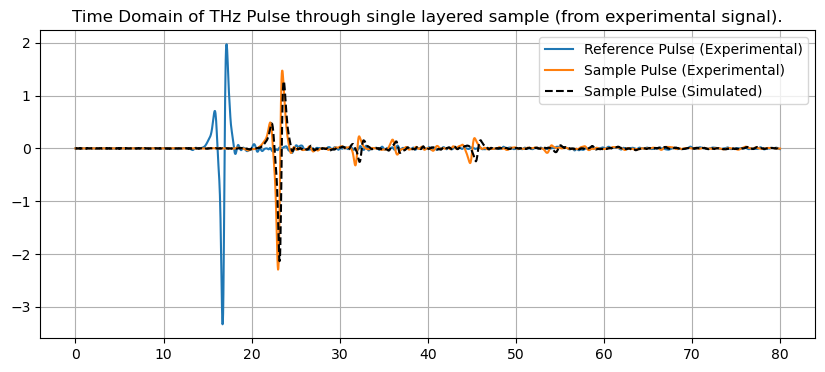

In [9]:
# Inintial simulation
n_init = [1.9820, 3.4000]
k_init = [0.0071, 0.0054]
d_init = [  1e-3, 0.4e-3]

layers= [(n_init[i] - 1j*k_init[i], d_init[i]) for i in range(2)]

T_exp, y_exp = simulate_parallel(x_exp, layers, deltat,noise_level=0.002)
y_exp = y_exp[:L].detach().cpu().numpy()

initial_loss = mae_loss(true_x_exp, y_exp)
print(f"Initial loss: {initial_loss}")

plt.figure(figsize=(10,4))
plt.title('Time Domain of THz Pulse through single layered sample (from experimental signal).')

plt.plot(t_r, x_exp, label='Reference Pulse (Experimental)')
plt.plot(t_r, true_x_exp, label='Sample Pulse (Experimental)')
plt.plot(t_r, y_exp, label='Sample Pulse (Simulated)', color = 'black', linestyle = '--')

plt.legend()
plt.grid()
#plt.savefig("Quartzsi plots /Quartz plot.png")
plt.show()

### With optimizer

In [10]:
def log_cosh_loss(y_pred, y_test):
    # Log-Cosh(x) = log((exp(x) + exp(-x)) / 2)
    # A numerically stable version is:
    # log(cosh(x)) ≈ |x| + log(1 + exp(-2|x|)) - log(2)
    diff = y_pred - y_test
    return torch.mean(torch.log(torch.cosh(diff + 1e-12)))

In [11]:
def find_optimal_params(initial_guess = (n_init, k_init, d_init), n_iters = 5000, print_step = 1000):

    n10, k10, d10, n20, k20, d20 = n_init[0], k_init[0], d_init[0], n_init[1], k_init[1], d_init[1]

    n1 = torch.tensor(1.0, requires_grad = True)
    k1 = torch.tensor(1.0, requires_grad = True)
    d1 = torch.tensor(1.0, requires_grad = True)
    n2 = torch.tensor(1.0, requires_grad = True)
    k2 = torch.tensor(1.0, requires_grad = True)
    d2 = torch.tensor(1.0, requires_grad = True)

#     k1 = torch.tensor(0.0, requires_grad = False)
#     k2 = torch.tensor(0.0, requires_grad = False)

    n1s, k1s, d1s  = [n1.clone().detach()*n10], [k1.clone().detach()*k10], [d1.clone().detach()*d10]
    n2s, k2s, d2s  = [n2.clone().detach()*n20], [k2.clone().detach()*k20], [d2.clone().detach()*d20]

    true_x_exp_tens = torch.tensor(true_x_exp, requires_grad=False)

    learning_rate = 1e-4
    optimizer = torch.optim.Adam([n1, k1, d1, n2, k2, d2], lr=learning_rate)

    layers = [(n1*n10 - 1j*k1*k10, d1*d10), (n2*n20 - 1j*k2*k20, d2*d20)]
    T_exp, y_exp = simulate_parallel(x_exp, layers, deltat)

    loss = (true_x_exp_tens - y_exp[:L]).abs().mean() +  log_cosh_loss(true_x_exp_tens, y_exp[:L])
    
    losses = [loss.clone().detach()]
    
    print(f"Epoch={1:6d}, n1={n1.item()*n10:2e}, k1={k1.item()*k10:2e}, d1={d1.item()*d10:2e} - n2={n2.item()*n20:2e}, k2={k2.item()*k20:2e}, d2={d2.item()*d20:2e} - Loss={loss.item():2e}")
    
    for i_iter in range(1, n_iters):

#         if i_iter > 5000:
#             k1.requires_grad = True
#             k2.requires_grad = True
            
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()
        
        layers = [(n1*n10 - 1j*k1*k10, d1*d10), (n2*n20 - 1j*k2*k20, d2*d20)]

        T_exp, y_exp = simulate_parallel(x_exp, layers, deltat)

        loss = (true_x_exp_tens - y_exp[:L]).abs().mean() + log_cosh_loss(true_x_exp_tens, y_exp[:L])

        with torch.no_grad():

            losses.append(loss.clone().detach())

            if i_iter in [n_iters - 1] or (i_iter + 1)%print_step == 0:
                lr = optimizer.param_groups[0]["lr"]
                print(f"Epoch={i_iter+1:6d}, n1={n1.item()*n10:2e}, k1={k1.item()*k10:2e}, d1={d1.item()*d10:2e} - n2={n2.item()*n20:2e}, k2={k2.item()*k20:2e}, d2={d2.item()*d20:2e} - Loss={loss.item():2e}")

            n1s.append(n1.clone().detach()*n10)
            k1s.append(k1.clone().detach()*k10)
            d1s.append(d1.clone().detach()*d10)

            n2s.append(n2.clone().detach()*n20)
            k2s.append(k2.clone().detach()*k20)
            d2s.append(d2.clone().detach()*d20)

    # Plot history
    fig = plt.figure(figsize=(12, 4))
    plt.title("Optimization process")
    plt.plot(losses[1:])
    plt.ylabel('Loss')
    plt.xlabel('Iteration')
    plt.yscale('log')
    plt.show()

    return np.array([n1s, k1s, d1s, n2s, k2s, d2s, losses])

In [12]:
def nkds_from_trajectory(trajectory):
    best_params = trajectory.T[-1][:-1].reshape(2,3).T
    labels = ['n', 'k', 'd']
    for i, vs in enumerate(best_params):
        print(f"{labels[i]}_init = [{', '.join([f'{v:6f}' for v in vs])}]")
    print()
    print(f"Loss: {trajectory.T[-1][-1]}")
    return best_params

In [13]:
def plot_pulses(ns, ks, ds):

    layers_try = [(ns[i] - 1j*ks[i], ds[i]) for i in range(2)]

    T_exp_try, y_exp_try = simulate_parallel(x_exp, layers_try, deltat)

    y_exp_try = y_exp_try[:L].detach().cpu().numpy()

    fig = plt.figure(figsize=(8, 4))
    plt.title('Time Domain of THz Pulse through single layered sample (from experimental signal).')
    plt.plot(true_x_exp, label = 'Sample Pulse (Experimental)', color = 'C1')
    plt.plot(y_exp_try, label = 'Best modified (Simulated)', color = 'black', alpha = 0.75, linestyle = '--')
    plt.legend()
    plt.grid()
    #plt.savefig("Quartzsi plots /Quartz plot.png")
    plt.show()

In [14]:
n_iters = 6000

Epoch=     1, n1=1.982000e+00, k1=7.100000e-03, d1=1.000000e-03 - n2=3.400000e+00, k2=5.400000e-03, d2=4.000000e-04 - Loss=4.659777e-02
Epoch=  1000, n1=1.982185e+00, k1=6.405163e-03, d1=9.851822e-04 - n2=3.359884e+00, k2=4.875392e-03, d2=3.913510e-04 - Loss=6.045526e-03
Epoch=  2000, n1=1.983007e+00, k1=5.702274e-03, d1=9.847097e-04 - n2=3.364272e+00, k2=4.334793e-03, d2=3.907263e-04 - Loss=5.535330e-03
Epoch=  3000, n1=1.981577e+00, k1=5.082325e-03, d1=9.853637e-04 - n2=3.374415e+00, k2=3.850715e-03, d2=3.895645e-04 - Loss=5.155905e-03
Epoch=  4000, n1=1.977303e+00, k1=4.497601e-03, d1=9.875301e-04 - n2=3.392803e+00, k2=3.382864e-03, d2=3.874823e-04 - Loss=4.836408e-03
Epoch=  5000, n1=1.969434e+00, k1=4.078528e-03, d1=9.914858e-04 - n2=3.422023e+00, k2=2.985050e-03, d2=3.842622e-04 - Loss=4.640546e-03
Epoch=  6000, n1=1.962626e+00, k1=3.944580e-03, d1=9.950451e-04 - n2=3.453451e+00, k2=2.708440e-03, d2=3.806814e-04 - Loss=4.563600e-03


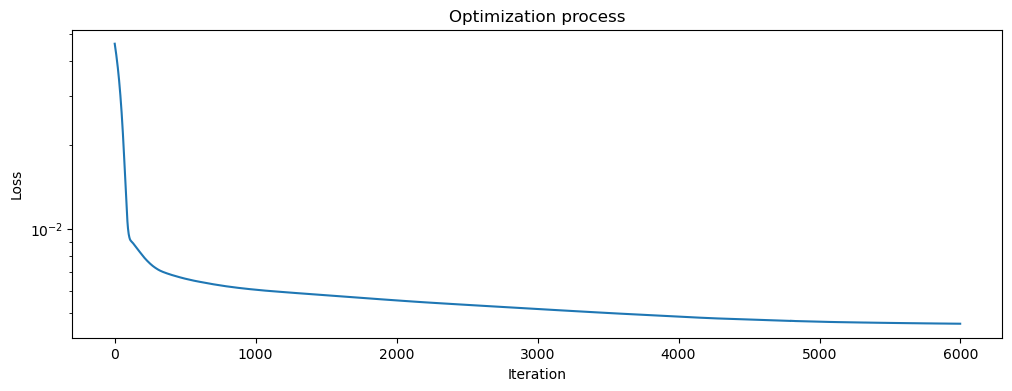

In [15]:
# Inintial simulation
n_init = [1.9820, 3.4000]
k_init = [0.0071, 0.0054]
d_init = [  1e-3, 0.4e-3]

trajectory1 = find_optimal_params(initial_guess = (n_init, k_init, d_init), n_iters=n_iters)

Epoch=     1, n1=1.900000e+00, k1=7.100000e-03, d1=9.000000e-04 - n2=3.400000e+00, k2=5.400000e-03, d2=4.000000e-04 - Loss=7.385978e-02
Epoch=  1000, n1=1.954500e+00, k1=7.144345e-03, d1=9.446346e-04 - n2=3.431404e+00, k2=5.546907e-03, d2=4.078382e-04 - Loss=2.101227e-02
Epoch=  2000, n1=1.990440e+00, k1=6.194256e-03, d1=9.809863e-04 - n2=3.331037e+00, k2=4.867415e-03, d2=3.946158e-04 - Loss=5.953995e-03
Epoch=  3000, n1=1.988857e+00, k1=5.435272e-03, d1=9.818094e-04 - n2=3.341236e+00, k2=4.278860e-03, d2=3.934230e-04 - Loss=5.442557e-03
Epoch=  4000, n1=1.984871e+00, k1=4.799804e-03, d1=9.837594e-04 - n2=3.361732e+00, k2=3.780400e-03, d2=3.910039e-04 - Loss=5.064335e-03
Epoch=  5000, n1=1.975842e+00, k1=4.260335e-03, d1=9.882733e-04 - n2=3.393968e+00, k2=3.331046e-03, d2=3.873855e-04 - Loss=4.766920e-03
Epoch=  6000, n1=1.966750e+00, k1=3.962792e-03, d1=9.928662e-04 - n2=3.433653e+00, k2=2.980639e-03, d2=3.829499e-04 - Loss=4.609728e-03


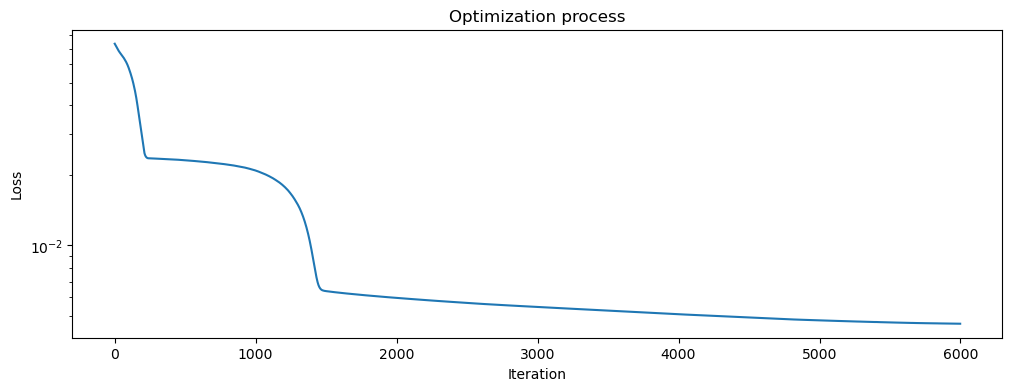

In [16]:
# Inintial simulation
n_init = [1.90, 3.4000]
k_init = [0.0071, 0.0054]
d_init = [ 900.0e-6, 0.4e-3]

trajectory2 = find_optimal_params(initial_guess = (n_init, k_init, d_init), n_iters=n_iters)

Epoch=     1, n1=2.010000e+00, k1=7.100000e-03, d1=9.000000e-04 - n2=3.400000e+00, k2=5.400000e-03, d2=4.000000e-04 - Loss=3.038853e-02
Epoch=  1000, n1=2.013127e+00, k1=6.410834e-03, d1=9.684178e-04 - n2=3.276452e+00, k2=4.873403e-03, d2=4.007882e-04 - Loss=6.438350e-03
Epoch=  2000, n1=2.002799e+00, k1=5.473798e-03, d1=9.750005e-04 - n2=3.285895e+00, k2=4.173105e-03, d2=3.999950e-04 - Loss=5.572400e-03
Epoch=  3000, n1=1.994364e+00, k1=4.798266e-03, d1=9.791130e-04 - n2=3.320981e+00, k2=3.650136e-03, d2=3.957858e-04 - Loss=5.145348e-03
Epoch=  4000, n1=1.979963e+00, k1=4.274973e-03, d1=9.861770e-04 - n2=3.376014e+00, k2=3.212072e-03, d2=3.894523e-04 - Loss=4.801496e-03
Epoch=  5000, n1=1.968037e+00, k1=4.021699e-03, d1=9.922008e-04 - n2=3.427563e+00, k2=2.869228e-03, d2=3.836542e-04 - Loss=4.616652e-03
Epoch=  6000, n1=1.960504e+00, k1=3.930546e-03, d1=9.961132e-04 - n2=3.463104e+00, k2=2.558066e-03, d2=3.796365e-04 - Loss=4.546077e-03


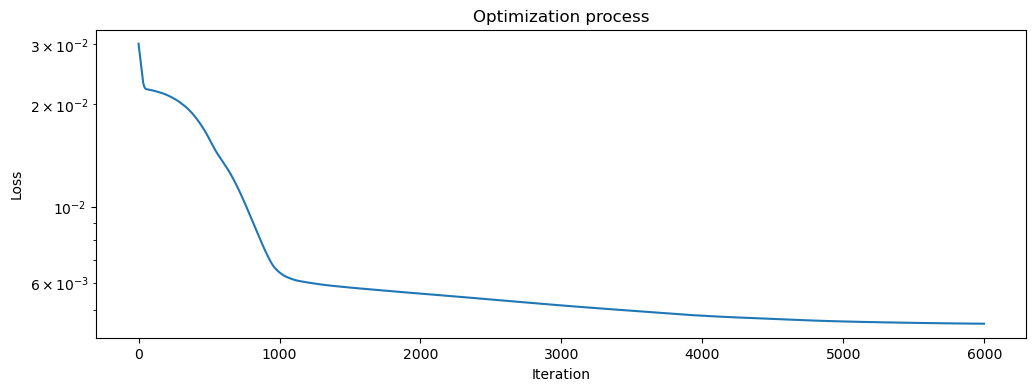

In [17]:
# Inintial simulation
n_init = [2.01, 3.4000]
k_init = [0.0071, 0.0054]
d_init = [ 900.0e-6, 0.4e-3]

trajectory3 = find_optimal_params(initial_guess = (n_init, k_init, d_init), n_iters=n_iters)

In [18]:
# # Inintial simulation
# n_init = [1.70, 3.6000]
# k_init = [0.0011, 0.00254]
# d_init = [ 200.0e-6, 0.1e-3]

# trajectory4 = find_optimal_params(initial_guess = (n_init, k_init, d_init), n_iters=n_iters)

In [19]:
trajectories = [trajectory1, trajectory2, trajectory3] #, trajectory4]

Trajectory: 1

n_init = [1.962626, 3.453451]
k_init = [0.003945, 0.002708]
d_init = [0.000995, 0.000381]

Loss: 0.0045636001401833355


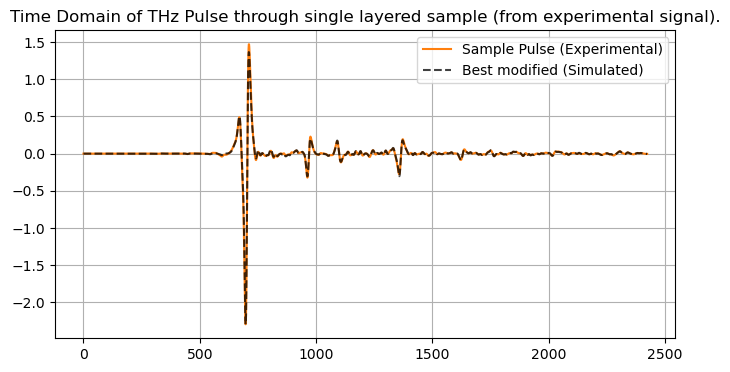

Trajectory: 2

n_init = [1.966750, 3.433654]
k_init = [0.003963, 0.002981]
d_init = [0.000993, 0.000383]

Loss: 0.004609727927073915


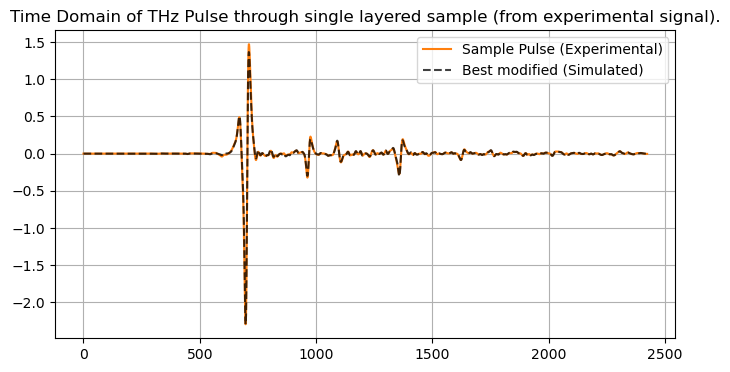

Trajectory: 3

n_init = [1.960504, 3.463104]
k_init = [0.003931, 0.002558]
d_init = [0.000996, 0.000380]

Loss: 0.004546076545929698


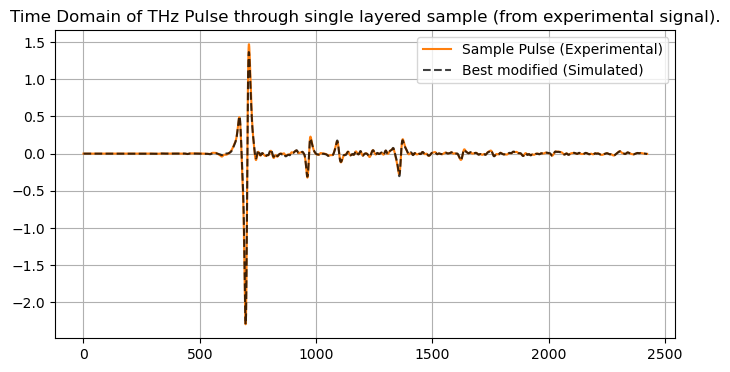

In [20]:
for i, traj in enumerate(trajectories):
    print(f"Trajectory: {i+1}\n")
    traj_ns, traj_ks, traj_ds = nkds_from_trajectory(traj)
    plot_pulses(traj_ns, traj_ks, traj_ds)

In [21]:
inds = {'n1': 0, 'k1': 1, 'd1': 2, 'n2': 3, 'k2': 4, 'd2': 5}

In [22]:
def calculate_3d_loss_landscape(x, y, x_iter = 100, y_iter = 100, pm = 0.5, original_params = None):
    loss_landscape = []

    if original_params is None:
        min_loss_traj = np.inf
        best_traj = 0
        for i, traj in enumerate(trajectories):
            if traj[-1][-1] < min_loss_traj:
                best_pars = traj.T[-1][:-1]
                best_traj = i
                min_loss_traj = traj[-1][-1]

        vs = {k:best_pars[v] for k,v in inds.items()}
    else:
        vs = original_params.copy()
        
    xs = np.linspace((1-pm)*vs[x], (1+pm)*vs[x], x_iter)
    ys = np.linspace((1-pm)*vs[y], (1+pm)*vs[y], y_iter)
    
    for xi in xs:
        for yi in ys:
            vs[x], vs[y] = xi, yi

            layers_try = [(vs['n1'] - 1j*vs['k1'], vs['d1']),
                          (vs['n2'] - 1j*vs['k2'], vs['d2'])]

            T_exp_try, y_exp_try = simulate_parallel(x_exp, layers_try, deltat)
            y_exp_try = y_exp_try[:L]  #.detach().cpu().numpy()
            loss = log_cosh_loss(y_exp_try.detach(), true_x_exp)
#             loss = mae_loss(true_x_exp, y_exp_try)
            loss_landscape.append(loss)  

    X, Y = np.meshgrid(xs, ys)
    return X, Y, np.array(loss_landscape).reshape(x_iter, y_iter)

In [23]:
def plot_3d_loss_landscape_and_trajectories(x, y, X, Y, loss_land, res = 200):

    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(projection='3d')

    ax.plot_surface(X, Y, loss_land, cmap='terrain', alpha=0.6, antialiased=True, linewidth=0, rcount=res, ccount=res)

    for i, traj in enumerate(trajectories):
        ax.scatter(traj[inds[x]], traj[inds[y]], traj[-1], marker='.', color = f"C{i}", s = 0.1, label = f"Trajectory {i+1}")
        ax.scatter(traj[inds[x]][-1], traj[inds[y]][-1], traj[-1][-1], marker='*', color = f"C{i}")
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_zlabel('loss')
    plt.legend()
    plt.show()

In [24]:
X, Y, loss_landscape = {}, {}, {}

C:\Users\Θόδωρας\AppData\Local\Temp\ipykernel_13088\3638492084.py:5: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  diff = y_pred - y_test
c:\Miniconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


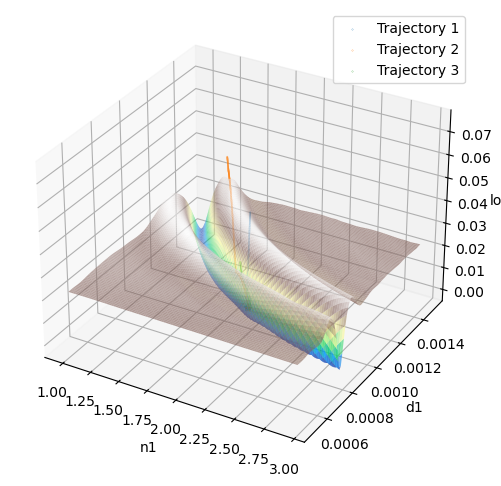

In [25]:
x, y = 'n1', 'd1'
X[x], Y[y], loss_landscape[f'{x}-{y}'] = calculate_3d_loss_landscape(x, y, original_params = or_params)

plot_3d_loss_landscape_and_trajectories('n1', 'd1', X['n1'], Y['d1'], loss_landscape['n1-d1'])

C:\Users\Θόδωρας\AppData\Local\Temp\ipykernel_13088\3638492084.py:5: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  diff = y_pred - y_test


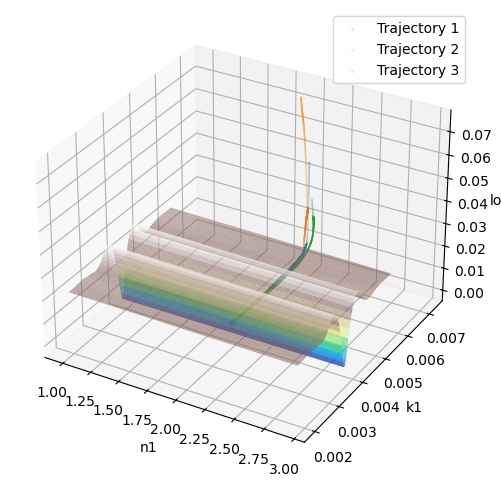

In [26]:
x, y = 'n1', 'k1'
X[x], Y[y], loss_landscape[f'{x}-{y}'] = calculate_3d_loss_landscape(x, y, original_params = or_params)

plot_3d_loss_landscape_and_trajectories('n1', 'k1', X['n1'], Y['k1'], loss_landscape['n1-k1'])

C:\Users\Θόδωρας\AppData\Local\Temp\ipykernel_13088\3638492084.py:5: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  diff = y_pred - y_test


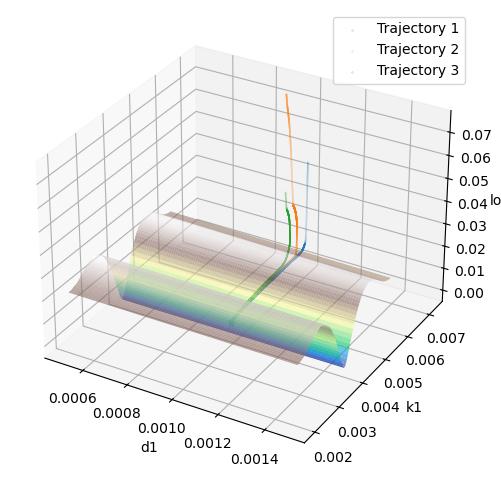

In [27]:
x, y = 'd1', 'k1'
X[x], Y[y], loss_landscape[f'{x}-{y}'] = calculate_3d_loss_landscape(x, y, original_params = or_params)

plot_3d_loss_landscape_and_trajectories('d1', 'k1', X['d1'], Y['k1'], loss_landscape['d1-k1'])

C:\Users\Θόδωρας\AppData\Local\Temp\ipykernel_13088\3638492084.py:5: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  diff = y_pred - y_test


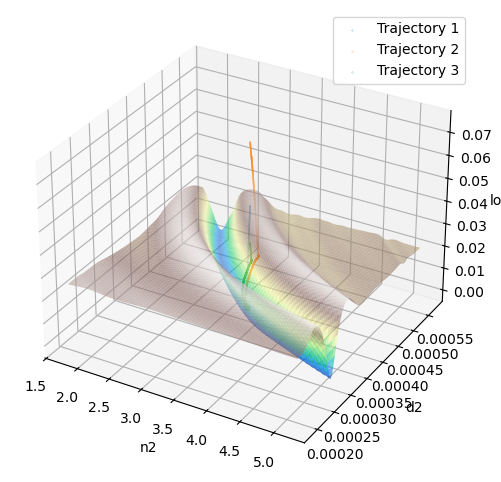

In [28]:
x, y = 'n2', 'd2'
X[x], Y[y], loss_landscape[f'{x}-{y}'] = calculate_3d_loss_landscape(x, y, original_params = or_params)

plot_3d_loss_landscape_and_trajectories('n2', 'd2', X['n2'], Y['d2'], loss_landscape['n2-d2'])

C:\Users\Θόδωρας\AppData\Local\Temp\ipykernel_13088\3638492084.py:5: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  diff = y_pred - y_test


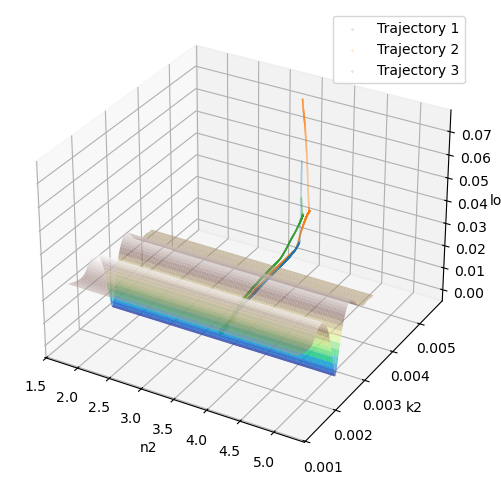

In [29]:
x, y = 'n2', 'k2'
X[x], Y[y], loss_landscape[f'{x}-{y}'] = calculate_3d_loss_landscape(x, y, original_params = or_params)

plot_3d_loss_landscape_and_trajectories('n2', 'k2', X['n2'], Y['k2'], loss_landscape['n2-k2'])

C:\Users\Θόδωρας\AppData\Local\Temp\ipykernel_13088\3638492084.py:5: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  diff = y_pred - y_test


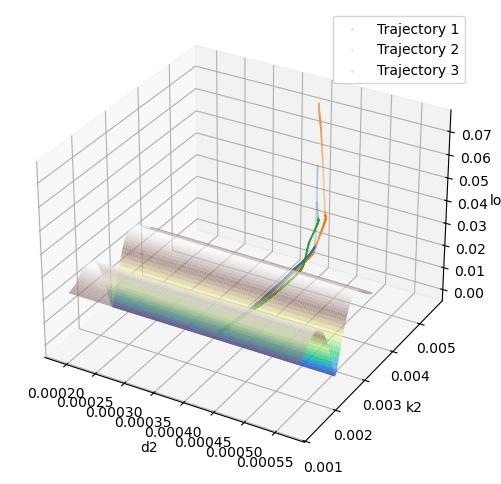

In [30]:
x, y = 'd2', 'k2'
X[x], Y[y], loss_landscape[f'{x}-{y}'] = calculate_3d_loss_landscape(x, y, original_params = or_params)

plot_3d_loss_landscape_and_trajectories('d2', 'k2', X['d2'], Y['k2'], loss_landscape['d2-k2'])

In [31]:
def plot_axis(ax, x, y, X, Y, loss_land):
    ax.contourf(X, Y, loss_land, cmap='plasma', alpha=0.8)

    for i, traj in enumerate(trajectories):
        ax.scatter(traj[inds[x]], traj[inds[y]], marker='.', label = f"Trajectory {i+1}")

    ax.set_xlabel(x)
    ax.set_ylabel(y)

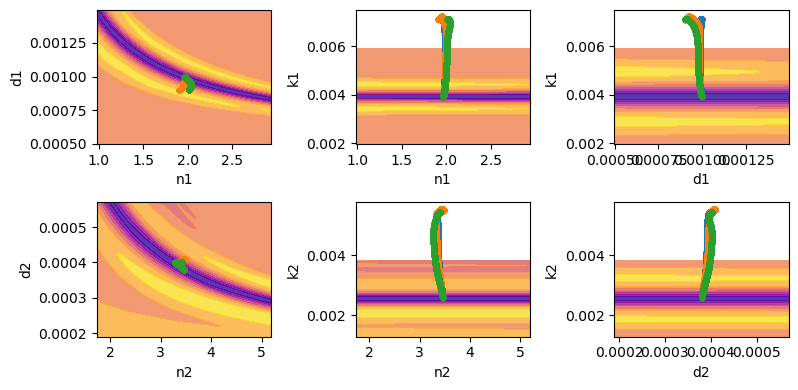

In [32]:
fig, ax = plt.subplots(2, 3, figsize=(8,4))

plot_axis(ax[0,0], 'n1', 'd1', X['n1'], Y['d1'], loss_landscape['n1-d1'])
plot_axis(ax[0,1], 'n1', 'k1', X['n1'], Y['k1'], loss_landscape['n1-k1'])
plot_axis(ax[0,2], 'd1', 'k1', X['d1'], Y['k1'], loss_landscape['d1-k1'])
plot_axis(ax[1,0], 'n2', 'd2', X['n2'], Y['d2'], loss_landscape['n2-d2'])
plot_axis(ax[1,1], 'n2', 'k2', X['n2'], Y['k2'], loss_landscape['n2-k2'])
plot_axis(ax[1,2], 'd2', 'k2', X['d2'], Y['k2'], loss_landscape['d2-k2'])

plt.tight_layout()
plt.show()

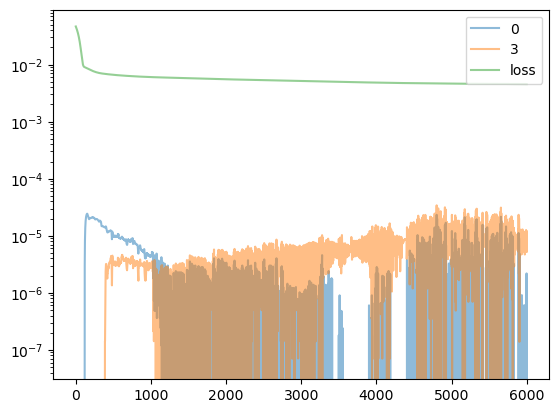

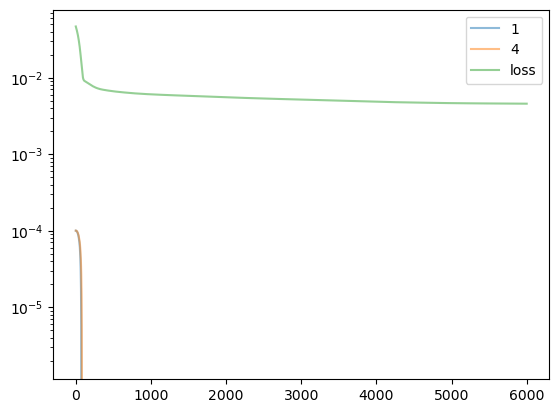

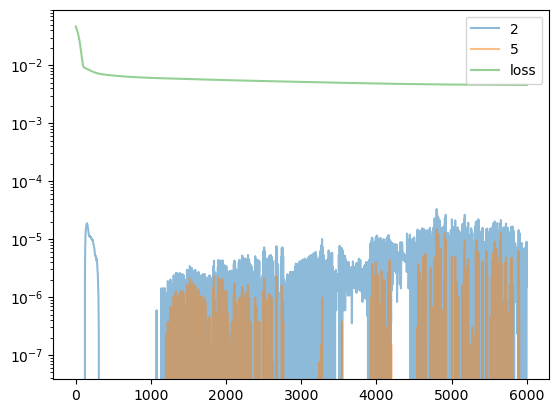

In [33]:
for j in range(3):
    fig = plt.figure()
    for i in range(j,6,3):
        plt.plot(np.diff(trajectory1[i])/trajectory1[i][1:], label=i, alpha=0.5)
    plt.plot(trajectory1[-1], label='loss', alpha=0.5)
    plt.yscale('log')
    plt.legend()
    plt.show()

In [34]:
# res = 200 

# fig, ax = plt.subplots(1, 3, subplot_kw={'projection': '3d'}, figsize=(8, 5))

# ax[0].plot_surface(nX, dY, n1_d1_loss.reshape(n_iter, d_iter), cmap='terrain', alpha=0.6,
#                 antialiased=True, linewidth=0, rcount=res, ccount=res)
# ax[0].scatter(n1s, d1s, losses, marker='.', color ='red')
# ax[0].set_xlabel('n1')
# ax[0].set_ylabel('d1')
# ax[0].set_zlabel('loss')

# ax[1].plot_surface(nX, kY, n1_k1_loss.reshape(n_iter, k_iter), cmap='terrain', alpha=0.6,
#                 antialiased=True, linewidth=0, rcount=res, ccount=res)
# ax[1].scatter(n1s, k1s, losses, marker='.', color ='red')
# ax[1].set_xlabel('n1')
# ax[1].set_ylabel('k1')
# ax[1].set_zlabel('loss')

# ax[2].plot_surface(kX, dY, k1_d1_loss.reshape(k_iter, d_iter), cmap='terrain', alpha=0.6,
#                 antialiased=True, linewidth=0, rcount=res, ccount=res)
# ax[2].scatter(k1s, d1s, losses, marker='.', color ='red')
# ax[2].set_xlabel('k1')
# ax[2].set_ylabel('d1')
# ax[2].set_zlabel('loss')

# plt.tight_layout()
# plt.show()

In [35]:
# fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8,3))
# ax1.contourf(nX, dY, n1_d1_loss.reshape(n_iter, d_iter), cmap='viridis') # Standard 2D filled contour
# ax1.plot(n1s, d1s, 'r')

# ax2.contourf(nX, kY, n1_k1_loss.reshape(n_iter, k_iter), cmap='viridis') # Standard 2D filled contour
# ax2.plot(n1s, k1s, 'r')

# ax3.contourf(kX, dY, k1_d1_loss.reshape(k_iter, d_iter), cmap='viridis') # Standard 2D filled contour
# ax3.plot(k1s, d1s, 'r')

# plt.tight_layout()
# plt.show()